# Table of number of expected events for various fluxes

This notebook shows how to compute the number of expected events in KM3NeT/ARCA for a given input neutrino flux. In particular, we focus on the fluxes presented in the Supplementary materials of the paper i.e., IceCube Single Power-Law best-fits and various models.

In [2]:
import sys

import numpy as np
import pandas as pd
from scipy.integrate import trapezoid
from scipy.interpolate import interp1d

path = "../../../uhe-event-v1.0/"
sys.path.append(path + "/src")
from fluxmethods import SinglePowerLawFlux, SEDFlux

# Inputs

### KM3NeT inputs

The sky-averaged all-flavour $\nu+\bar\nu$ effective area $A_{\rm eff}(E)$ is used to compute the flux needed to get one expected event in KM3NeT, assuming a per-flavour $\nu+\bar\nu$ neutrino spectrum $\Phi(E)$.
$$N_{\rm exp} = 4\pi \times T_{\rm livetime} \times \times 1/2 \times \int A_{\rm eff}(E) \times \Phi(E) {\rm d}E$$

In [3]:
# Feldman-Cousins intervals computed with ROOT.TFeldmanCousins (hardcoded here to avoid ROOT import)
feldmancousins_intervals = {
    "1sigma": np.array([0.3679, 2.7506]),
    "2sigma": np.array([0.0466, 5.1433]),
    "3sigma": np.array([0.0028, 8.3077]),
}

In [4]:
livetime_arca = 335 * 86400  # in seconds
df_aeff_arca = pd.read_json(path + "/data/supplementary/simulations/effective_area_brighttrackselection_allflavour_skyavg.json")

x_aeff_arca, y_aeff_arca = df_aeff_arca["Energy [GeV]"], df_aeff_arca["Aeff [cm^2]"]
f_aeff_arca = interp1d(x_aeff_arca, y_aeff_arca, bounds_error=False, fill_value=0)

energy5_evt, energy50_evt, energy95_evt = 7.24e7, 2.18e8, 2.57e9 # RANGE OF ENERGY IN GeV

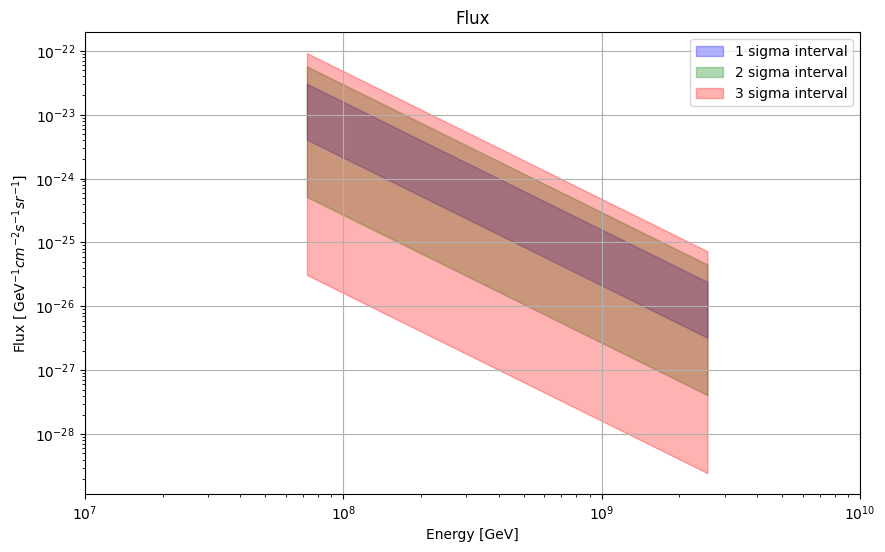

In [14]:
import matplotlib.pyplot as plt

# Define the energy range
energy_range = np.logspace(np.log10(energy5_evt), np.log10(energy95_evt), 200)

x = np.logspace(np.log10(energy5_evt), np.log10(energy95_evt), 200)
acceptance_arca = trapezoid(y=x**-2 * f_aeff_arca(x), x=x)
flux_arca = 1 / (4 * np.pi * livetime_arca * acceptance_arca)

# Calculate the flux intervals for each energy value
# flux_1sigma = feldmancousins_intervals["1sigma"][:, np.newaxis] * energy_range**-2 * f_aeff_arca(energy_range)
# flux_2sigma = feldmancousins_intervals["2sigma"][:, np.newaxis] * energy_range**-2 * f_aeff_arca(energy_range)
# flux_3sigma = feldmancousins_intervals["3sigma"][:, np.newaxis] * energy_range**-2 * f_aeff_arca(energy_range)
flux_1sigma = feldmancousins_intervals["1sigma"][:, np.newaxis] * flux_arca * energy_range**-2
flux_2sigma = feldmancousins_intervals["2sigma"][:, np.newaxis] * flux_arca * energy_range**-2
flux_3sigma = feldmancousins_intervals["3sigma"][:, np.newaxis] * flux_arca * energy_range**-2

# Plot the flux intervals
plt.figure(figsize=(10, 6))
plt.fill_between(energy_range, flux_1sigma[0], flux_1sigma[1], color='blue', alpha=0.3, label='1 sigma interval')
plt.fill_between(energy_range, flux_2sigma[0], flux_2sigma[1], color='green', alpha=0.3, label='2 sigma interval')
plt.fill_between(energy_range, flux_3sigma[0], flux_3sigma[1], color='red', alpha=0.3, label='3 sigma interval')

plt.xscale('log')
plt.yscale('log')
plt.xlim([1e7, 1e10])
plt.xlabel('Energy [GeV]')
plt.ylabel(r'Flux [$ \: \text{GeV}^{-1} cm^{-2} s^{-1} sr^{-1}] $')
plt.title('Flux')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Calculate the number of events for each sigma interval
n_events_central = 4 * np.pi * livetime_arca * trapezoid(flux_arca * energy_range**-2 * f_aeff_arca(energy_range), x=energy_range)
n_events_1sigma = 4 * np.pi * livetime_arca * trapezoid(feldmancousins_intervals["1sigma"][:, np.newaxis] * flux_arca * energy_range**-2 * f_aeff_arca(energy_range), x=energy_range)
n_events_2sigma = 4 * np.pi * livetime_arca * trapezoid(feldmancousins_intervals["2sigma"][:, np.newaxis] * flux_arca * energy_range**-2 * f_aeff_arca(energy_range), x=energy_range)
n_events_3sigma = 4 * np.pi * livetime_arca *  trapezoid(feldmancousins_intervals["3sigma"][:, np.newaxis] * flux_arca * energy_range**-2 * f_aeff_arca(energy_range), x=energy_range)

# Print the results
print("Number of events", n_events_central)
print("Number of events for 1 sigma interval:", n_events_1sigma)
print("Number of events for 2 sigma interval:", n_events_2sigma)
print("Number of events for 3 sigma interval:", n_events_3sigma)

Number of events 1.0
Number of events for 1 sigma interval: [0.3679 2.7506]
Number of events for 2 sigma interval: [0.0466 5.1433]
Number of events for 3 sigma interval: [2.8000e-03 8.3077e+00]
